# Clases no balanceadas - Inttroducción a Machine Leaning
Angélica Mata Zamora

## El problema de las clases no balanceadas

In [ ]:
# Importar Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score

In [3]:
# Generando los conjuntos desbalanceados:
# n: total de registros a generar
# p0: proporción de registros de la clase mayoritaria (valor 0)
# p1: proporción de registros de la clase minoritaria (valor 1): p1=1-p0
# Obviamente una proporción es complemento del otro, pero especificamos
# ambos para tener presente en todo momento el tipo de desbalanceo que tenemos.

def mis_conjuntos(n, p0, p1):

   X, y = make_classification(
       n_samples=n,             # Se generan "n" registros donde cada factor tiene una distribución gaussiana con varianza 1.
       n_classes=2,             # El conjunto de datos generado constará de dos clases diferentes.
       n_features=2,            # Habrá 2 variables de entrada (factores o variables independientes)
       n_redundant=0,           # No hay factores que sean redundantes, i.e., que uno sea combinación lineal de otros factores.
       n_clusters_per_class=1,  # Cada clase se agrupa alrededor de un único centro.
       weights=[p0, p1],        # [proporción_clase_negativa(0), proporción_clase_positiva(1)]  : p1=1-p0
       flip_y=0.,               # No existen datos mal etiquetados.
       class_sep=0.1,           # Valor que indican la distancia entre clases. Más grande, mayor distancia.
       random_state=0)

   return X,y


# Desplegando la matriz de confusión:
# (etiquetas_reales, etiquetas_de_predicciones)
def mi_cm(yreal, ypred):
  cm = confusion_matrix(yreal, ypred)

  txt = ['Verdaderos Negativos','Falsos Positivos','Falsos Negativos','Verdaderos Positivos']
  vf = [ '( VN )', '( FP )', '( FN )', '( VP )']
  frecuencia = ["{0:0.0f}".format(value) for value in cm.flatten()]
  porcentaje = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]

  labels = [f"{v1}\n{v2}\n{v3}\n{v4}" for v1, v2, v3, v4 in zip(txt,vf, frecuencia,porcentaje)]
  labels = np.asarray(labels).reshape(2,2)

  plt.figure(figsize=(6,4))
  ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Pastel1', cbar=False)
  ax.set(ylabel="Etiquetas Reales", xlabel="Etiquetas de Predicción")
  plt.show()

Dimensión de datos generados:
Datos de entrada X: (2000, 2)
Variable de salida y: (2000,)


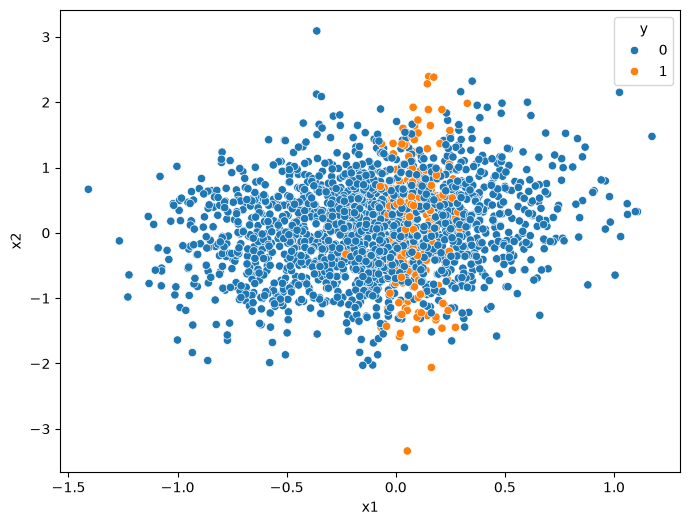

In [4]:
X,y = mis_conjuntos(2000, 0.9, 0.1)

print('Dimensión de datos generados:')
print('Datos de entrada X:', X.shape)
print('Variable de salida y:', y.shape)

# Los transformamos en un DataFrame de Pandas:
df = pd.DataFrame(X, columns=['x1','x2'])
df['y'] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='x1', y='x2', hue='y');

In [5]:
# Realicemos una partición considerando solo al conjunto de etrenamiento (70%) y al de validación (30%).
# Esto ya que para los ejemplos que deseamos ilustrar, no requerimos de un conjunto de prueba.

X,y = mis_conjuntos(2000, 0.9, 0.1)

X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.70, random_state=1, stratify=y)

In [6]:
# Inicializamos el modelo de regresión logística con los parámetros predeterminados:
modelo = LogisticRegression()

# Entrenamos con los datos de entrenamiento:
modelo.fit(X_train, y_train)

# Realizamos las predicciones con los datos de validación:
yhat = modelo.predict(X_val)

# Veamos el desempeño en cuanto exactitud (accuracy) del modelo:
print('Exactitud del modelo con los datos de prueba: %.1f%%' % (100*modelo.score(X_val,y_val)))

Exactitud del modelo con los datos de prueba: 90.0%


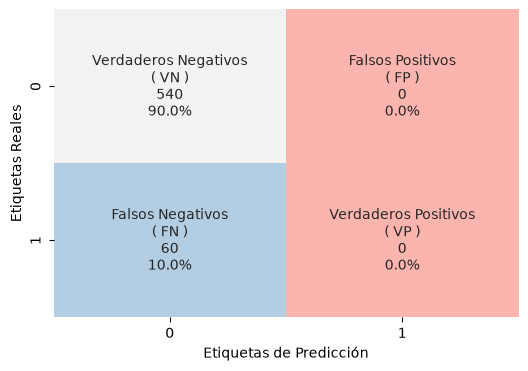

In [7]:
mi_cm(y_val, yhat)

In [8]:
from sklearn.dummy import DummyClassifier     # importamos el clasificador

Matriz de confusión del conjunto de validación del modelo Dummy
con la estrategia de mayor frecuencia:


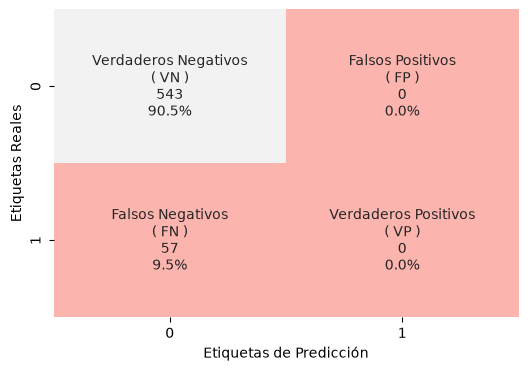

None

Proporción en clase negativa del conjunto de validación:  0.905

Proporción en clase negativa del conjunto de entrenamiento:  0.8978571428571429


In [9]:
X,y = mis_conjuntos(2000, 0.9, 0.1)    # generamos de nuevo las dos clases con desbalanceo 90% y 10%

X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.70, random_state=3)   # realizamos la partición.

modeloDummy = DummyClassifier(strategy='most_frequent')    # Inicializamos el modelo Dummy con el crierio de
                                                           # predecir siempre con el valor de la clase de mayor frecuencia.

modeloDummy.fit(X_train, y_train)       # entrenamos con los conjuntos de entrenamiento

yhat = modeloDummy.predict(X_val)       # realizamos las predicciones con el conjunto de validación, el cual sabemos
                                        # que siempre será igual a cero, ya que representa a la case mayoritaria.


# Obtenemos los valores de la matriz de confusión del modelo Dummy:
print('Matriz de confusión del conjunto de validación del modelo Dummy\ncon la estrategia de mayor frecuencia:')
# Observa que no necesariamente debe ser exactamente igual a 0.90 el valor de los VN,
# por lo que comentamos de la aleatoriedad de la partición; pero se espera en dado caso un valor muy cercano:
print(mi_cm(y_val, yhat))

print('\nProporción en clase negativa del conjunto de validación: ', 1 - y_val.sum() / y_val.shape[0])

# De nuevo, para este ejemplo se espera un valor cercano o igual al 90% en el siguiente resultado:
print('\nProporción en clase negativa del conjunto de entrenamiento: ', (1-y_train.sum() / y_train.shape[0]))

Matriz de confusión en el conjunto de Validación.
Modelo Dummy con la estrategia "stratified":


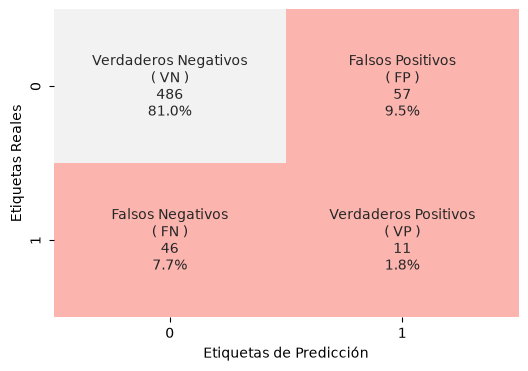

None

Proporción del conjunto de validación:  0.905

Proporción del conjunto de entrenamiento:  0.8978571428571429


In [10]:
modeloDummy = DummyClassifier(strategy='stratified', random_state=7)   # ahora hacemos predicciones aleatorias de la misma
                                                                       # manera en que están estratificadas las clases.

modeloDummy.fit(X_train, y_train, sample_weight=None)
yhat = modeloDummy.predict(X_val)

print('Matriz de confusión en el conjunto de Validación.')
print('Modelo Dummy con la estrategia "stratified":')
print(mi_cm(y_val, yhat))

print('\nProporción del conjunto de validación: ', 1 - y_val.sum() / y_val.shape[0])
print('\nProporción del conjunto de entrenamiento: ', (1-y_train.sum() / y_train.shape[0]))

Exactitud con datos de Validación: 60.3%


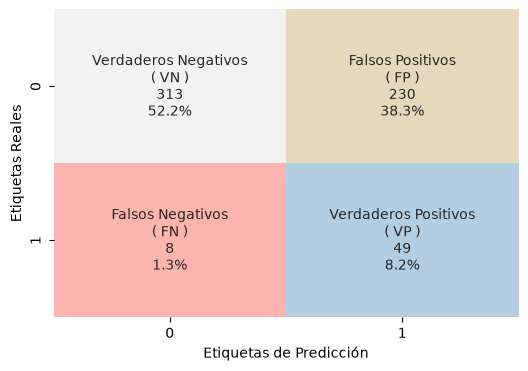

In [11]:
modelo = LogisticRegression(class_weight={0:0.1, 1:0.9})   # A la clase positiva minoritaria (1) la castigamos más
                                                           # para provocar que no se equivoque tanto.

# Entrenamos el modelo con los datos de entrenamiento:
modelo.fit(X_train, y_train)

# Obtenemos las predicciones con el conjunto de validación:
yhat = modelo.predict(X_val)

# Obtenemos el desempeño con el valor de la exactitud (accuracy):
print('Exactitud con datos de Validación: %.1f%%' % (100*modelo.score(X_val,y_val)))
mi_cm(y_val, yhat)

In [12]:
delta = np.linspace(.05, .4, 8)   # generamos 8 valores entre 0.05 y 0.4 para generar los diferentes pesos de las clases.
tabla = list()

for w in delta:
  modelo = LogisticRegression(class_weight={0:w, 1:(1-w)})
  modelo.fit(X_train, y_train)
  yhat = modelo.predict(X_val)

  acc = 100*modelo.score(X_val,y_val)

  cm = confusion_matrix(y_val, yhat)

  tot = cm.sum()

  vn = 100*cm[0,0] / tot
  fp = 100*cm[0,1] / tot
  fn = 100*cm[1,0] / tot
  vp = 100*cm[1,1] / tot

  tabla.append([w, 1-w, acc, vn, fp, fn, vp])

print(tabulate(tabla,
               headers=["peso_clase_0","peso_clase_1", "Exactitud(%)", "VN(%)", "FP(%)", "FN(%)", "VP(%)"],
               tablefmt="github",
               floatfmt=".2f",
               colalign=("center","center","center",)))

|  peso_clase_0  |  peso_clase_1  |  Exactitud(%)  |   VN(%) |   FP(%) |   FN(%) |   VP(%) |
|----------------|----------------|----------------|---------|---------|---------|---------|
|      0.05      |      0.95      |     36.67      |   27.17 |   63.33 |    0.00 |    9.50 |
|      0.10      |      0.90      |     60.33      |   52.17 |   38.33 |    1.33 |    8.17 |
|      0.15      |      0.85      |     71.67      |   70.67 |   19.83 |    8.50 |    1.00 |
|      0.20      |      0.80      |     82.83      |   82.83 |    7.67 |    9.50 |    0.00 |
|      0.25      |      0.75      |     87.83      |   87.83 |    2.67 |    9.50 |    0.00 |
|      0.30      |      0.70      |     89.67      |   89.67 |    0.83 |    9.50 |    0.00 |
|      0.35      |      0.65      |     90.33      |   90.33 |    0.17 |    9.50 |    0.00 |
|      0.40      |      0.60      |     90.50      |   90.50 |    0.00 |    9.50 |    0.00 |


## Más métricas para medir el desempeño:

In [13]:
# En el siguiente ejemplo generaremos ahora un conjunto con 80% y 20% de desbalanceo:

X,y = mis_conjuntos(2000, 0.8, 0.2)
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.70, random_state=3)

delta = np.linspace(.05, .3, 6)
tabla = list()

for w in delta:
  modelo = LogisticRegression(class_weight={0:w, 1:(1-w)}, C=100)
  modelo.fit(X_train, y_train)
  yhat = modelo.predict(X_val)

  acc = 100*modelo.score(X_val,y_val)

  cm = confusion_matrix(y_val, yhat)

  tot = cm.sum()

  vn = 100*cm[0,0] / tot
  fp = 100*cm[0,1] / tot
  fn = 100*cm[1,0] / tot
  vp = 100*cm[1,1] / tot

  precision = vp / ( vp+fp)
  recall = vp / (vp+fn)
  f1score = 2*vp / (2*vp+fp+fn)
  especificidad = vn / (vn+fp)
  gmean = np.sqrt(recall * especificidad)

  tabla.append([w, (1-w), acc, vn, fp, fn, vp, precision, recall, f1score, gmean])

print(tabulate(tabla,
         headers=["w (clase 0)","(1-w) (clase 1)","Exact(%)", "VN(%)", "FP(%)", "FN(%)", "VP(%)", "precision", "recall", "f1score", "gmean"],
         tablefmt="github",
         floatfmt=".2f"
         ))

|   w (clase 0) |   (1-w) (clase 1) |   Exact(%) |   VN(%) |   FP(%) |   FN(%) |   VP(%) |   precision |   recall |   f1score |   gmean |
|---------------|-------------------|------------|---------|---------|---------|---------|-------------|----------|-----------|---------|
|          0.05 |              0.95 |      44.00 |   24.50 |   56.00 |    0.00 |   19.50 |        0.26 |     1.00 |      0.41 |    0.55 |
|          0.10 |              0.90 |      50.17 |   30.67 |   49.83 |    0.00 |   19.50 |        0.28 |     1.00 |      0.44 |    0.62 |
|          0.15 |              0.85 |      56.17 |   36.67 |   43.83 |    0.00 |   19.50 |        0.31 |     1.00 |      0.47 |    0.67 |
|          0.20 |              0.80 |      64.00 |   47.00 |   33.50 |    2.50 |   17.00 |        0.34 |     0.87 |      0.49 |    0.71 |
|          0.25 |              0.75 |      63.17 |   54.83 |   25.67 |   11.17 |    8.33 |        0.25 |     0.43 |      0.31 |    0.54 |
|          0.30 |              0.7

## Técnicas de balanceo: submuestreo y sobremuestreo

In [14]:
# Importemos algunos otros módulos que requeriremos:

from sklearn.metrics import classification_report, make_scorer
from imblearn.metrics import geometric_mean_score, classification_report_imbalanced
from sklearn.model_selection import cross_val_score, cross_validate, RepeatedStratifiedKFold

In [15]:
# Generemos una partición de 85%-15% sin el argumento estratificado al hacer la partición:

X,y = mis_conjuntos(2000, 0.85, 0.15)
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.70, random_state=11)

In [16]:
model = LogisticRegression(class_weight=None,    # primero ejecutamos el entrenamiento sin balanceo, ni ponderación de clases.
                           random_state=11)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)   # aplicamos validación cruzada con estratificación y repetición.

# Calculemos de una sola vez todas las métricas que hemos definido:
misscores = {'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1', 'gmean':make_scorer(geometric_mean_score) }

scoresSin = cross_validate(model, X, y,
                           scoring=misscores,
                           cv=cv,
                           n_jobs=-1   # trata de usar todos los recursos a los cuales tengamos acceso y en dado caso aplicar paralelización.
                           )

# cada uno de los valores de estas métricas se pueden tomar como puntos de partida (baseline):
print('mean Accuracy: %.3f \nmean Precision: %.3f \nmean Recall: %.3f \nmean F1: %.3f \nGmean: %.3f' % (np.mean(scoresSin['test_accuracy']),
                                                                          np.mean(scoresSin['test_precision']),
                                                                          np.mean(scoresSin['test_recall']),
                                                                          np.mean(scoresSin['test_f1']),
                                                                          np.mean(scoresSin['test_gmean'])
                                                                          ))

mean Accuracy: 0.849 
mean Precision: 0.000 
mean Recall: 0.000 
mean F1: 0.000 
Gmean: 0.000


/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.14/site-packages/sklea

In [17]:
model = LogisticRegression(class_weight={0:.15,1:.85}, # ahora ponderamos las clases en orden inverso a su distribución, aproximadamente.
                           random_state=11)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)

# Podemos evaluar varias métricas en un mismo proceso de entrenamiento:
misscores = {'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1', 'gmean':make_scorer(geometric_mean_score) }

scoresSin = cross_validate(model, X, y,            # Recuerda que este proceso de cross_validate con CV, separa
                           scoring=misscores,      # internamente Train y Val para evitar el filtrado de información.
                           cv=cv,
                           n_jobs=-1)

# cada uno de los valores de estas métricas se pueden tomar como baseline:
print('mean Accuracy: %.3f \nmean Precision: %.3f \nmean Recall: %.3f \nmean F1: %.3f \nmean Gmean: %.3f' % (np.mean(scoresSin['test_accuracy']),
                                                                          np.mean(scoresSin['test_precision']),
                                                                          np.mean(scoresSin['test_recall']),
                                                                          np.mean(scoresSin['test_f1']),
                                                                          np.mean(scoresSin['test_gmean'])
                                                                          ))

mean Accuracy: 0.641 
mean Precision: 0.274 
mean Recall: 0.844 
mean F1: 0.414 
mean Gmean: 0.715


In [18]:
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

from imblearn.over_sampling import SMOTE

from imblearn.combine import SMOTEENN
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline

In [19]:
def get_models_underoversampling():
  models, names = list(), list()

  # RO
  models.append(RandomOverSampler())
  names.append('RandOver')
  # RU
  models.append(RandomUnderSampler())
  names.append('RandUnder')
  # TL
  models.append(TomekLinks())
  names.append('TomekLinks')
  # ENN
  models.append(EditedNearestNeighbours())
  names.append('ENN')
  #SMOTE
  models.append(SMOTE())
  names.append('SMOTE')
  # SMOTEENN
  models.append(SMOTEENN())
  names.append('SMOTEENN')
  #SMOTETek
  models.append(SMOTETomek())
  names.append('SMOTETek')


  return models, names

In [20]:
# Generemos de nuevo clases con 85% y 15% de desbalanceo y con un 70% en el conjunto de entrenamiento:
X,y = mis_conjuntos(2000, 0.85, 0.15)
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.70, random_state=1)


modelosOU, nombres = get_models_underoversampling()
resultados = list()

for i in range(len(modelosOU)):

  model = LogisticRegression(class_weight='balanced', random_state=5)  # ahora probemos con el argumento "balanced"

  kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

  pipe = make_pipeline(( modelosOU[i]), ( model))

  metric = {'accuracy':'accuracy', 'recall':'recall', 'gmean':make_scorer(geometric_mean_score) }

  scores = cross_validate(pipe,
                          X, y,
                          scoring=metric,
                          cv=kfold)

  resultados.append(scores)

  print('>> %s:\nmean Accuracy: %.3f \nmean Recall: %.3f  \nGmean: %.3f' % (nombres[i],
                                                                           np.mean(scores['test_accuracy']),
                                                                           np.mean(scores['test_recall']),
                                                                           np.mean(scores['test_gmean'])
                                                                           ))

>> RandOver:
mean Accuracy: 0.642 
mean Recall: 0.830  
Gmean: 0.710
>> RandUnder:
mean Accuracy: 0.640 
mean Recall: 0.837  
Gmean: 0.711
>> TomekLinks:
mean Accuracy: 0.637 
mean Recall: 0.853  
Gmean: 0.715
>> ENN:
mean Accuracy: 0.623 
mean Recall: 0.909  
Gmean: 0.721
>> SMOTE:
mean Accuracy: 0.642 
mean Recall: 0.842  
Gmean: 0.714
>> SMOTEENN:
mean Accuracy: 0.622 
mean Recall: 0.927  
Gmean: 0.725
>> SMOTETek:
mean Accuracy: 0.640 
mean Recall: 0.853  
Gmean: 0.717


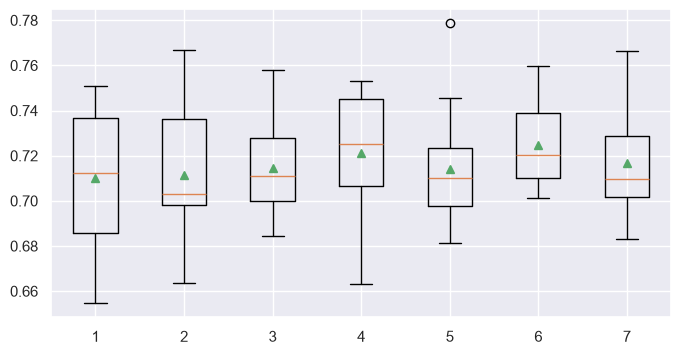

In [22]:
sns.set(rc={'figure.figsize':(8,4)})
bpGmean = list()
for i in range(len(resultados)):
  rr = resultados[i]['test_gmean']
  bpGmean.append(rr)

plt.boxplot(bpGmean, label=nombres, showmeans=True)
plt.show()

In [23]:
clf = LogisticRegression(class_weight='balanced',
                         random_state=1 )

kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

mOU = SMOTEENN()

pipe = make_pipeline(( mOU), ( model))

pipe.fit(X_train,y_train)

yhat = pipe.predict(X_val)

print('Accuracy score: %.4f' % pipe.score(X_val, y_val))
print('Precision score: %.4f' % precision_score(y_val, yhat))
print('Recall score: %.4f' % recall_score(y_val, yhat))
print('Gmean score: %.4f' % geometric_mean_score(y_val, yhat))

Accuracy score: 0.6133
Precision score: 0.2716
Recall score: 0.9551
Gmean score: 0.7273


In [24]:
print(classification_report(y_val, yhat))

              precision    recall  f1-score   support

           0       0.99      0.55      0.71       511
           1       0.27      0.96      0.42        89

    accuracy                           0.61       600
   macro avg       0.63      0.75      0.57       600
weighted avg       0.88      0.61      0.67       600



In [25]:

print(classification_report_imbalanced(y_val,yhat))

                   pre       rec       spe        f1       geo       iba       sup

          0       0.99      0.55      0.96      0.71      0.73      0.51       511
          1       0.27      0.96      0.55      0.42      0.73      0.55        89

avg / total       0.88      0.61      0.90      0.67      0.73      0.51       600

